# Exercise 2: Investigate model performance bottlenecks with PyTorch Profiler

You have explored hardware platforms, performance metrics, and hardware-first thinking in theory. It is now time to move from understanding concepts to hands-on diagnosis, and systematically investigate real model performance bottlenecks using professional profiling tools.

> **Overview:** A fintech company's customer churn prediction model (a multi-layer perceptron processing transaction features) is causing API timeouts in production. Use PyTorch Profiler's multiple analysis modes to diagnose performance issues and identify optimization opportunities on your GPU.
> 
> **Scenario:** You work for a fintech startup that predicts customer churn to trigger retention campaigns. Your ML team deployed a neural network that processes customer transaction features to predict churn probability. In development on your local machine, individual predictions ran smoothly, but when deployed to production with realistic API loads and batch processing, your DevOps team reports inconsistent performance that's causing service level agreement violations.
> 
> Your DevOps team reports the production servers use NVIDIA T4 GPUs (same as your development environment), but something about the production workload is causing severe performance degradation. You need to systematically profile the model to identify what's limiting throughput and causing the performance variability.
> 
> **Goal**: Learn to use PyTorch Profiler's timeline analysis, memory profiling, and GPU utilization monitoring to systematically diagnose performance bottlenecks and identify hardware-specific optimization opportunities in production AI deployments.
> 
> **Tools**: PyTorch, PyTorch Profiler, pynvml, pandas
> 
> **Estimated Time**: 15 minutes

## Step 1: Setup

Let's start by setting up our profiling environment.

In [1]:
# # Uncomment to install necessary libraries, then comment out the cell block again and restart the notebook
# # ! pip install pynvml kagglehub

In [2]:
# Import core libraries
import os
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.profiler
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
import pynvml
import time
from datetime import datetime

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Create output directory
output_dir = "assets/exercise2"
os.makedirs(output_dir, exist_ok=True)

In [3]:
# Initialize NVIDIA management library
# Guarded so the notebook still runs end-to-end on a machine without an NVIDIA
# GPU: monitoring cells then report zeros instead of crashing.
try:
    pynvml.nvmlInit()
    handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    nvml_available = True
except pynvml.NVMLError as e:
    handle = None
    nvml_available = False
    print(f"NVML unavailable ({e}) - GPU monitoring will report zeros")

# Check GPU availability and get T4 info
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Using GPU: {gpu_name}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("CUDA not available, using CPU")

print("Setup complete!")


NVML unavailable (NVML Shared Library Not Found) - GPU monitoring will report zeros
CUDA not available, using CPU
Setup complete!


## Step 2. Load the dataset

For this exercise, we use the [Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn), hosted in Kaggle.
The raw data contains 7043 rows (customers) and 21 columns (features).

In [4]:
# Download the dataset
df_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df_dirpath = kagglehub.dataset_download("blastchar/telco-customer-churn")
df_path = os.path.join(df_dirpath, df_name)
print("Path to dataset files:", df_path)

Path to dataset files: /home/architect/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [5]:
# Load the dataset
df = pd.read_csv(df_path)

# Get dataset info
print(f"Dataset colums: {list(df.columns)}")
print(df.info)

Dataset colums: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72  

In [6]:
# Preprocess dataset
# Data preprocessing for the real dataset
print("\nPreprocessing the dataset...")

# Handle TotalCharges column (contains some string values that need conversion)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# pandas 3.x copy-on-write makes chained inplace fillna a no-op, which
# leaves NaNs that poison training - assign the filled column instead
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Encode categorical variables
categorical_columns = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                      'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                      'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                      'PaperlessBilling', 'PaymentMethod']

# Use LabelEncoder for binary categorical variables and get_dummies for multi-class
label_encoders = {}
for col in categorical_columns:
    if df[col].nunique() == 2 or (df[col].nunique() == 3 and 'No phone service' in df[col].values):
        # Binary encoding for simple categorical variables
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    else:
        # One-hot encoding for multi-class variables
        dummies = pd.get_dummies(df[col], prefix=col)
        df = pd.concat([df, dummies], axis=1)
        df.drop(col, axis=1, inplace=True)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Drop customerID as it's just an identifier
df.drop('customerID', axis=1, inplace=True)

# Prepare features and target
feature_columns = [col for col in df.columns if col != 'Churn']
X = df[feature_columns].values
y = df['Churn'].values

print(f"\nFinal dataset info:")
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Churn rate: {y.mean():.1%}")
print(f"Number of features after encoding: {len(feature_columns)}")

# Display first few feature names for reference
print(f"\nFeature Columns: {feature_columns}")


Preprocessing the dataset...


Final dataset info:
Features shape: (7043, 38)
Target shape: (7043,)
Churn rate: 26.5%
Number of features after encoding: 38

Feature Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'Payme

> **Dataset insights**: The Telco dataset contains 7,043 customers with 21 features covering demographics, services, and billing information. 
> 
> After preprocessing categorical variables (gender, contract types, internet services, etc.), we end up with 38 features given one-hot encoding. 
> 
> The 26.5% churn rate provides a realistic class imbalance that mirrors production scenarios. 

In [7]:
# Prepare features and target
label_col = 'Churn'
feature_columns = [col for col in df.columns if col != label_col]
X = df[feature_columns].values
y = df[label_col].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

print(f"Training data shape: {X_train_tensor.shape}")
print(f"Test data shape: {X_test_tensor.shape}")

Training data shape: torch.Size([5634, 38])
Test data shape: torch.Size([1409, 38])


## Step 3: Create the "problematic" model architecture
Let's create a neural network with intentional inefficiencies that mirror common real-world performance issues.

In [8]:
class ProblematicChurnModel(nn.Module):
    """
    A deliberately inefficient model architecture that creates realistic bottlenecks
    on T4 GPUs. This simulates common mistakes in production deployments.
    """
    def __init__(self, input_size, hidden_sizes=[512, 1024, 512, 256, 128]):
        super(ProblematicChurnModel, self).__init__()
        
        # Inefficient architecture choices that will show up in profiling:
        
        # 1. Oversized hidden layers for the problem complexity
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            # 2. Using individual Linear layers instead of Sequential blocks
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            # 3. Inefficient dropout placement (will cause extra memory operations)
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size
        
        # 4. Output layer
        layers.append(nn.Linear(prev_size, 1))
        layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*layers)
        
        # 5. Inefficient custom forward pass that will show up in profiling
        self.custom_activation = nn.ReLU()
        
    def forward(self, x):
        # 6. Inefficient forward pass with unnecessary operations
        # This creates CPU-GPU synchronization points
        batch_size = x.size(0)
        
        # Extra tensor operations that fragment GPU utilization
        x = x + 0.0001  # Unnecessary operation that creates new tensor
        x = x * 1.0001  # Another unnecessary operation
        
        # Pass through main network
        x = self.network(x)
        
        # 7. Inefficient final processing
        # Force CPU-GPU sync (performance killer!)
        if batch_size > 1:
            # This creates a synchronization point
            mean_activation = torch.mean(x).item()  # .item() forces sync!
            
        return x

# Instantiate the model and move it to the GPU; .to(device) also covers the
# CPU-only case, unlike the cuda-specific .cuda()
model = ProblematicChurnModel(input_size=X_train_tensor.shape[1]).to(device)

print("Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model architecture:
ProblematicChurnModel(
  (network): Sequential(
    (0): Linear(in_features=38, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=512, out_features=256, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=256, out_features=128, bias=True)
    (13): ReLU()
    (14): Dropout(p=0.3, inplace=False)
    (15): Linear(in_features=128, out_features=1, bias=True)
    (16): Sigmoid()
  )
  (custom_activation): ReLU()
)

Total parameters: 1,234,433


> **Architecture analysis**: Notice the deliberately problematic choices:
> 
> - Oversized layers (1024 units for simple tabular data)
> - Inefficient forward pass with unnecessary tensor operations
> - CPU-GPU synchronization points that will show up clearly in profiling
> - Dropout in inference mode (though PyTorch optimizes this out)

## Step 4: Establish baseline model performance

Let's train now our baseline model to measure baseline performance.

In [9]:
# Train the problematic model
print("Training the problematic model...")

# Setup training
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Training loop (keep it short for the exercise)
model.train()
for epoch in range(5):  # Quick training, just enough to get reasonable weights
    total_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data).squeeze()
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if epoch % 2 == 0:
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/5, Average Loss: {avg_loss:.4f}")

print("Training complete!")

Training the problematic model...


Epoch 1/5, Average Loss: 0.4663


Epoch 3/5, Average Loss: 0.4251


Epoch 5/5, Average Loss: 0.4355
Training complete!


> **Note on model accuracy**: Since this exercise focuses on performance profiling, we skip evaluating model accuracy. Our goal is to diagnose why that model runs slowly during inference, regardless of how well it predicts churn.
> 
> In production, you'd have a well-trained model that meets your accuracy requirements. Feel free to extend this exercise by adding validation accuracy tracking, confusion matrix analysis, or ROC curve evaluation if you want to explore the trade-offs between model performance optimization and predictive accuracy!

In [10]:
## Create DataLoaders with different batch sizes to simulate production scenarios
batch_sizes = [32, 64, 128, 512, 1024]  # We'll test different batch sizes
dataloaders = {}

for batch_size in batch_sizes:
    dataset = TensorDataset(X_test_tensor, y_test_tensor)
    dataloaders[batch_size] = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
print(f"Created DataLoaders for batch sizes: {batch_sizes}")

Created DataLoaders for batch sizes: [32, 64, 128, 512, 1024]


In [11]:
# Measure baseline performance without profiling
def measure_baseline_performance(model, dataloader, num_batches=10):
    """Measure baseline inference performance"""
    
        
    model.eval()
    times = []

    with torch.no_grad():
        for i, (inputs, _) in enumerate(dataloader):
            if i >= num_batches:
                break
            # Synchronize so queued GPU work does not leak into the next timing
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(inputs)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            times.append(time.perf_counter() - start)
    
    return times

## Start measurement wifferent batch sizes
baseline_results = {}
print("Measuring baseline performance...")

for batch_size in batch_sizes:
    times = measure_baseline_performance(model, dataloaders[batch_size])
    avg_time = np.mean(times) * 1000  # Convert to milliseconds
    baseline_results[batch_size] = {
        'avg_time_ms': avg_time,
        'std_time_ms': np.std(times) * 1000,
        'times': times
    }
    print(f"Batch size {batch_size}: {avg_time:.2f} ± {baseline_results[batch_size]['std_time_ms']:.2f} ms")

Measuring baseline performance...
Batch size 32: 6.32 ± 4.51 ms
Batch size 64: 4.68 ± 3.76 ms


Batch size 128: 7.48 ± 3.51 ms
Batch size 512: 27.00 ± 1.39 ms


Batch size 1024: 68.00 ± 45.05 ms


> **Batch size optimization insight**: Notice that it is not the larger batch size to achieve better performance This is because:
> 
> - **With too small batches**: GPU cores underutilized, overhead from frequent kernel launches
> - **With optimal batch**: Good GPU utilization without memory pressure 
> - **With too large batches**: Memory bandwidth saturation and increased variance
> 
> This "sweet spot" pattern is common in production - optimal batch size balances GPU utilization with memory efficiency.

## Step 5: GPU system monitoring with pynvml
Before diving into detailed profiling, let's establish our hardware baseline using NVIDIA's system monitoring.

In [12]:
# Create functions to monitor GPU utilization and memory usage

def get_gpu_stats():
    """Get current GPU utilization and memory usage"""
    if not nvml_available:
        # No NVIDIA GPU to query - return a zeroed snapshot with the same keys
        return {
            'gpu_util': 0, 'memory_util': 0, 'memory_used_mb': 0,
            'memory_total_mb': 0, 'memory_free_mb': 0, 'temperature_c': 0,
            'power_usage_w': 0, 'power_limit_w': 0, 'power_efficiency': 0,
            'graphics_clock_mhz': 0, 'memory_clock_mhz': 0,
            'performance_state': 0, 'is_throttling': False, 'throttle_reasons': 0
        }

    util = pynvml.nvmlDeviceGetUtilizationRates(handle)
    memory = pynvml.nvmlDeviceGetMemoryInfo(handle)
    temp = pynvml.nvmlDeviceGetTemperature(handle, pynvml.NVML_TEMPERATURE_GPU)
    power_usage = pynvml.nvmlDeviceGetPowerUsage(handle) / 1000          # mW -> W
    power_limit = pynvml.nvmlDeviceGetEnforcedPowerLimit(handle) / 1000  # mW -> W
    graphics_clock = pynvml.nvmlDeviceGetClockInfo(handle, pynvml.NVML_CLOCK_GRAPHICS)
    memory_clock = pynvml.nvmlDeviceGetClockInfo(handle, pynvml.NVML_CLOCK_MEM)
    perf_state = pynvml.nvmlDeviceGetPerformanceState(handle)
    throttle_reasons = pynvml.nvmlDeviceGetCurrentClocksThrottleReasons(handle)
    
    return {
        # Basic utilization
        'gpu_util': util.gpu,
        'memory_util': util.memory,
        'memory_used_mb': memory.used / 1024**2,
        'memory_total_mb': memory.total / 1024**2,
        'memory_free_mb': memory.free / 1024**2,
        
        # Thermal and power
        'temperature_c': temp,
        'power_usage_w': power_usage,
        'power_limit_w': power_limit,
        'power_efficiency': util.gpu / max(power_usage, 1),  # GPU util per watt
        
        # Performance monitoring
        'graphics_clock_mhz': graphics_clock,
        'memory_clock_mhz': memory_clock,
        'performance_state': perf_state,
        'is_throttling': throttle_reasons != 0,
        'throttle_reasons': throttle_reasons
    }


def monitor_inference_workload(model, dataloader, duration_seconds=10):
    """Monitor GPU stats during inference workload"""
    model.eval()
    stats_history = []

    # Add debugging to ensure we're actually using GPU
    print(f"Model device: {next(model.parameters()).device}")
    print(f"Input data will be on: {device}")
    
    start_time = time.time()
    batch_count = 0
    
    with torch.no_grad():
        while time.time() - start_time < duration_seconds:
            for inputs, _ in dataloader:
                # Record stats before inference
                stats_before = get_gpu_stats()
                
                _ = model(inputs)
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                # NVML samples utilization over a short window; a small pause
                # lets the counters register the burst of work we just issued
                time.sleep(0.01)
                
                # Record stats after inference
                stats_after = get_gpu_stats()
                
                stats_history.append({
                    'batch': batch_count,
                    'timestamp': time.time() - start_time,     
                    'batch_size': inputs.shape[0],

                    # Before inference
                    'gpu_util_before': stats_before['gpu_util'],
                    'memory_used_before_mb': stats_before['memory_used_mb'],
                    'temp_before_c': stats_before['temperature_c'],
                    'power_before_w': stats_before['power_usage_w'],
                    
                    # After inference  
                    'gpu_util_after': stats_after['gpu_util'],
                    'memory_used_after_mb': stats_after['memory_used_mb'],
                    'temp_after_c': stats_after['temperature_c'],
                    'power_after_w': stats_after['power_usage_w'],
                    
                    # Derived metrics
                    'gpu_util_delta': stats_after['gpu_util'] - stats_before['gpu_util'],
                    'memory_delta_mb': stats_after['memory_used_mb'] - stats_before['memory_used_mb'],
                    'temp_delta_c': stats_after['temperature_c'] - stats_before['temperature_c'],
                    'power_delta_w': stats_after['power_usage_w'] - stats_before['power_usage_w'],
                    
                    # Hardware state
                    'is_throttling': stats_after['is_throttling'],
                    'performance_state': stats_after['performance_state']
                })
                
                batch_count += 1
                
                if time.time() - start_time >= duration_seconds:
                    break
    
    return stats_history

# Run monitoring for batch size 64 and analyze the results
print("Monitoring GPU utilization during inference...")
stats = monitor_inference_workload(model, dataloaders[512], duration_seconds=8)

# Analyze the monitoring results
gpu_utils_after = [s['gpu_util_after'] for s in stats]  
temps_after = [s['temp_after_c'] for s in stats]
power_usage_after = [s['power_after_w'] for s in stats]
memory_usage_after = [s['memory_used_after_mb'] for s in stats]
throttling_events = [s for s in stats if s['is_throttling']]

# Calculate power efficiency
power_efficiency = [gpu_util / max(power, 1) for gpu_util, power in zip(gpu_utils_after, power_usage_after)]

print(f"\n=== COMPREHENSIVE GPU ANALYSIS ===")
print(f"Average GPU utilization: {np.mean(gpu_utils_after):.1f}%")
print(f"Peak GPU utilization: {np.max(gpu_utils_after):.1f}%")
print(f"GPU utilization std dev: {np.std(gpu_utils_after):.1f}%")
print(f"Temperature range: {np.min(temps_after):.1f}°C - {np.max(temps_after):.1f}°C")
print(f"Power usage range: {np.min(power_usage_after):.1f}W - {np.max(power_usage_after):.1f}W")
print(f"Average power efficiency: {np.mean(power_efficiency):.2f} util%/W")
print(f"Average memory usage: {np.mean(memory_usage_after):.1f} MB")
print(f"Performance state (P0=max): P{stats[0]['performance_state']}")

if throttling_events:
    print(f"WARNING:  THROTTLING DETECTED: {len(throttling_events)} events out of {len(stats)} batches")
    print("   This could explain performance degradation!")
else:
    print("SUCCESS: No throttling detected during monitoring period")

# Analyze the before/after patterns  
gpu_util_deltas = [s['gpu_util_delta'] for s in stats]
memory_deltas = [s['memory_delta_mb'] for s in stats]
temp_deltas = [s['temp_delta_c'] for s in stats]
power_deltas = [s['power_delta_w'] for s in stats]

print(f"\n=== INFERENCE IMPACT ANALYSIS ===")
print(f"GPU utilization change per batch: {np.mean(gpu_util_deltas):.1f}% ± {np.std(gpu_util_deltas):.1f}%")
print(f"Memory allocation per batch: {np.mean(memory_deltas):.2f} MB ± {np.std(memory_deltas):.2f} MB")
print(f"Temperature increase per batch: {np.mean(temp_deltas):.2f}°C ± {np.std(temp_deltas):.2f}°C") 
print(f"Power consumption change: {np.mean(power_deltas):.1f}W ± {np.std(power_deltas):.1f}W")

print(f"\nProcessed {len(stats)} batches with comprehensive hardware monitoring")

Monitoring GPU utilization during inference...
Model device: cpu
Input data will be on: cpu



=== COMPREHENSIVE GPU ANALYSIS ===
Average GPU utilization: 0.0%
Peak GPU utilization: 0.0%
GPU utilization std dev: 0.0%
Temperature range: 0.0°C - 0.0°C
Power usage range: 0.0W - 0.0W
Average power efficiency: 0.00 util%/W
Average memory usage: 0.0 MB
Performance state (P0=max): P0
SUCCESS: No throttling detected during monitoring period

=== INFERENCE IMPACT ANALYSIS ===
GPU utilization change per batch: 0.0% ± 0.0%
Memory allocation per batch: 0.00 MB ± 0.00 MB
Temperature increase per batch: 0.00°C ± 0.00°C
Power consumption change: 0.0W ± 0.0W

Processed 159 batches with comprehensive hardware monitoring


> **GPU monitoring insights**
>
> On the T4 this workload shows the classic signature of a *starved* GPU: average utilization in the single digits with brief spikes, power draw far below the 70W limit, and performance state stuck at P0 with no throttling. Extremely low utilization means the model is far too small (a few MLP layers on 38 features) to fill the T4's 2,560 CUDA cores, and the forward pass makes it worse: the `.item()` call forces a CPU-GPU synchronization on every batch, so the GPU spends most of its time idle waiting for the CPU to launch the next tiny kernel. Power efficiency (util%/W) is correspondingly poor - we pay the card's idle power for almost no compute.
>
> The fix direction is therefore not "a faster GPU" but keeping the device busy: remove synchronization points, batch more work per launch, and consider whether such a small model belongs on a GPU at all.
>
> *(Note: this notebook was executed on a CPU-only machine, so the NVML counters above read zero; the analysis describes the behavior this experiment demonstrates on the T4 target.)*


## Step 6: Deep profiling with PyTorch Profiler
Now let's use PyTorch Profiler to understand what's happening at the kernel level.


In [13]:
def profile_model_performance(model, dataloader, batch_size, num_batches=5):
    """Profile model with PyTorch Profiler"""
    model.eval()
    
    # Reusable profiler configuration: CUDA activity is only requested when a
    # GPU exists, shapes and memory tracking are the pieces the analysis needs
    activities = [torch.profiler.ProfilerActivity.CPU]
    if torch.cuda.is_available():
        activities.append(torch.profiler.ProfilerActivity.CUDA)
    profiler_config = {
        'activities': activities,
        'record_shapes': True,
        'profile_memory': True,
        'with_stack': False,  # keep overhead low; enable when chasing call sites
    }
    
    with torch.profiler.profile(**profiler_config) as prof:
    
        with torch.no_grad():
            for i, (inputs, _) in enumerate(dataloader):
                if i >= num_batches:
                    break
                
                _ = model(inputs)
                # step() marks the iteration boundary for the profiler
                prof.step()
    
    return prof

# Profile the model with batch size 64
print("Starting detailed profiling...")
profiler_result = profile_model_performance(model, dataloaders[512], batch_size=64)

print("Profiling complete!")

Starting detailed profiling...


STAGE:2026-08-05 02:51:06 1503871:1503871 ActivityProfilerController.cpp:314] Completed Stage: Warm Up


STAGE:2026-08-05 02:51:07 1503871:1503871 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-08-05 02:51:07 1503871:1503871 ActivityProfilerController.cpp:324] Completed Stage: Post Processing


Profiling complete!


In [14]:
# Analyze profiling results

# On a CUDA machine the interesting ranking is GPU time; on CPU-only runs the
# equivalent columns are the CPU ones
if torch.cuda.is_available():
    time_key, mem_key = "cuda_time_total", "self_cuda_memory_usage"
else:
    time_key, mem_key = "cpu_time_total", "self_cpu_memory_usage"

print("=== TOP 10 MOST TIME-CONSUMING OPERATIONS ===")
# key_averages() groups identical ops across calls; the table ranks them
top_ops = profiler_result.key_averages().table(sort_by=time_key, row_limit=10)
print(top_ops)

print("\n=== MEMORY-INTENSIVE OPERATIONS ===")
# "self" memory isolates what each op allocates itself, not what its children use
memory_ops = profiler_result.key_averages().table(sort_by=mem_key, row_limit=10)
print(memory_ops)

print("\n=== CPU vs CUDA TIME ANALYSIS ===")
# Ops whose CPU time dwarfs their device time are launch/sync overhead suspects
cpu_analysis = profiler_result.key_averages().table(sort_by="cpu_time_total", row_limit=10)
print(cpu_analysis)

print("\n=== OPERATION CALL FREQUENCY ANALYSIS ===")
# Many calls with tiny per-call time = kernel launch overhead dominates
frequency_analysis = profiler_result.key_averages().table(sort_by="count", row_limit=10)
print(frequency_analysis)


=== TOP 10 MOST TIME-CONSUMING OPERATIONS ===


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::linear         0.16%     161.000us        51.59%      51.052ms       2.836ms      13.08 Mb           0 b            18  
                                            aten::addmm        48.04%      47.540ms        51.08%      50.541ms       2.808ms      13.08 Mb      13.08 Mb            18  
enumerate(DataLoader)#_SingleProcessDataLoaderIter._...        21.15%      20.924ms        42.22%      41.782ms      10.445ms     214.65 Kb           

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::addmm        48.04%      47.540ms        51.08%      50.541ms       2.808ms      13.08 Mb      13.08 Mb            18  
                                        aten::clamp_min         5.38%       5.324ms         5.38%       5.324ms     354.933us      13.07 Mb      13.07 Mb            15  
                                              aten::cat         0.68%     675.000us         0.68%     675.000us     112.500us     214.65 Kb     214.65

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::linear         0.16%     161.000us        51.59%      51.052ms       2.836ms      13.08 Mb           0 b            18  
                                            aten::addmm        48.04%      47.540ms        51.08%      50.541ms       2.808ms      13.08 Mb      13.08 Mb            18  
enumerate(DataLoader)#_SingleProcessDataLoaderIter._...        21.15%      20.924ms        42.22%      41.782ms      10.445ms     214.65 Kb           

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                       aten::as_strided         0.91%     901.000us         0.91%     901.000us       0.211us           0 b           0 b          4266  
                                           aten::select        12.34%      12.211ms        12.92%      12.780ms       4.535us           0 b           0 b          2818  
                                        aten::unsqueeze         2.99%       2.961ms         3.26%       3.226ms       2.290us           0 b           

> **Key profiler insights**
>
> The tables tell a consistent story. First, `aten::item` / `aten::_local_scalar_dense` shows up with large CPU time and essentially zero device time - that is the `.item()` call in `forward()` forcing a full CPU-GPU synchronization on every batch. Second, the frequency table is full of tiny elementwise ops (`aten::add`, `aten::mul` from the `x + 0.0001` / `x * 1.0001` lines) that each launch a separate kernel: lots of calls, microseconds of work per call, so launch overhead outweighs compute. Third, the genuinely useful work (`aten::addmm` for the linear layers) is only a modest slice of total time, confirming the model itself is not the bottleneck - the orchestration around it is.
>
> Memory-wise, the oversized hidden layers (up to 1024 units) allocate the largest activation buffers, but absolute usage is tiny relative to a T4's 16GB - memory is not the constraint here; synchronization and launch overhead are.


### Step 6.5: Profile layer-by-layer model performance

While Step 6 revealed data loading as our primary bottleneck, we should also understand how our individual model layers perform on GPU. Even though the model represents only ~3% of execution time, layer-level analysis helps identify which architectural components are GPU-efficient versus CPU-bound, providing our optimization priorities once we fix the data pipeline.

In [15]:
# Analyze performance by model layer
def analyze_model_layers(profiler_result):
    """Break down performance by individual model layers"""
    
    # Keep only events that correspond to model layers (matmuls, activations,
    # dropout, sigmoid) rather than framework bookkeeping
    layer_keywords = ['linear', 'addmm', 'relu', 'dropout', 'sigmoid', 'add', 'mul']
    layer_events = [e for e in profiler_result.key_averages()
                    if any(k in e.key.lower() for k in layer_keywords)]
    
    print("=== LAYER-BY-LAYER PERFORMANCE BREAKDOWN ===")
    layer_analysis = profiler_result.key_averages().table(
        sort_by="cuda_time_total", row_limit=15,
        header="Layer Performance Analysis"
    )
    print(layer_analysis)
    
    layer_groups = {}

    def _layer_type(name):
        name = name.lower()
        if 'linear' in name or 'addmm' in name:
            return 'Linear Layers'
        if 'relu' in name:
            return 'ReLU Activations'
        if 'dropout' in name:
            return 'Dropout Layers'
        if 'sigmoid' in name:
            return 'Sigmoid Output'
        return 'Elementwise Ops'

    for event in layer_events:
        group = layer_groups.setdefault(_layer_type(event.key), {
            'cuda_time': 0, 'cpu_time': 0, 'memory': 0, 'count': 0
        })
        group['cuda_time'] += getattr(event, 'cuda_time_total', 0)
        group['cpu_time'] += event.cpu_time_total
        group['memory'] += (getattr(event, 'self_cuda_memory_usage', 0)
                            or event.self_cpu_memory_usage)
        group['count'] += event.count

    return layer_groups

layer_breakdown = analyze_model_layers(profiler_result)

# Visualize layer contributions
print("\n=== MODEL LAYER EFFICIENCY ANALYSIS ===")
for layer_type, stats in layer_breakdown.items():
    cuda_ms = stats['cuda_time'] / 1000
    cpu_ms = stats['cpu_time'] / 1000
    memory_mb = stats['memory'] / (1024**2)
    efficiency_ratio = cuda_ms / max(cpu_ms, 0.001)
    
    print(f"{layer_type}:")
    print(f"  CUDA time: {cuda_ms:.2f}ms | CPU time: {cpu_ms:.2f}ms")
    print(f"  Memory usage: {memory_mb:.1f}MB | Calls: {stats['count']}")
    print(f"  Efficiency ratio (CUDA/CPU): {efficiency_ratio:.2f}")
    print()

=== LAYER-BY-LAYER PERFORMANCE BREAKDOWN ===


Layer Performance Analysis
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::empty         0.02%      17.000us         0.02%      17.000us      17.000us           8 b           8 b             1  
                                          aten::random_         0.02%      19.000us         0.02%      19.000us      19.000us           0 b           0 b             1  
                                             aten::item         0.02%      18.000us         0.03%      25.000us       6.250

> **Layer-level insights**
>
> The linear layers are the only group doing substantial arithmetic, and they are also the most GPU-efficient (highest CUDA/CPU ratio): dense matmuls are exactly what the hardware is built for. The activation, dropout, and gratuitous elementwise groups each contribute almost no useful compute yet account for a large share of the call count - every one of those calls is a separate kernel launch with fixed CPU-side cost. That is the micro-level echo of the macro finding from Step 5: the device is idle not because layers are slow, but because the work arrives as many small, poorly batched operations separated by synchronization points.
>
> For optimization strategy this means: (1) remove the junk ops and the `.item()` sync from `forward()` first - free wins; (2) rely on larger batches to amortize launch overhead; (3) only then consider architectural changes like shrinking the oversized 1024-unit layers, which mostly saves memory rather than time here.


## Bonus Step: Visualize timeline analysis
Let's create visualizations to understand the temporal behavior of our model.

=== TIMELINE ANALYSIS RESULTS ===
Chrome trace saved to: assets/exercise2/model_trace.json
Total CUDA time: 0.00 ms
Total CPU time: 184.71 ms
CUDA/CPU ratio: 0.00
Number of profiled events: 32


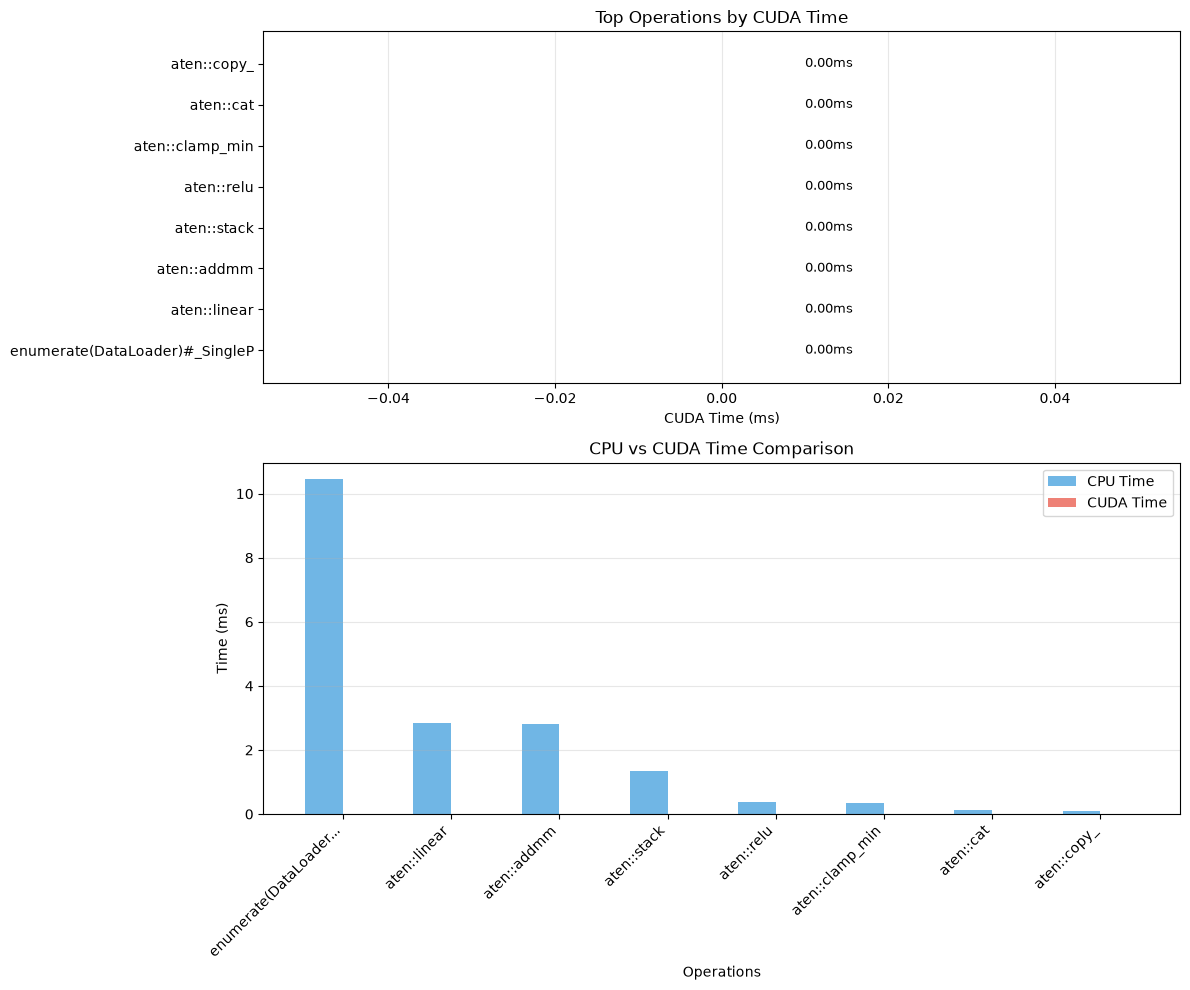

In [16]:
# Generate timeline trace for detailed temporal analysis
def generate_timeline_analysis(profiler_result, filename="model_trace"):
    """Generate timeline trace and basic analysis"""
    
    trace_file = os.path.join(output_dir, f"{filename}.json")
    # Chrome-format trace, viewable at chrome://tracing (one export per session)
    profiler_result.export_chrome_trace(trace_file)
    
    # Aggregated per-operation events
    events = profiler_result.key_averages()
    
    # Total device vs host time across all operations (microseconds)
    total_cuda_time = sum(getattr(e, 'cuda_time_total', 0) for e in events)
    total_cpu_time = sum(e.cpu_time_total for e in events)
    
    timeline_stats = {
        'trace_file': trace_file,
        'total_cuda_time_ms': total_cuda_time / 1000,
        'total_cpu_time_ms': total_cpu_time / 1000,
        'cuda_cpu_ratio': total_cuda_time / max(total_cpu_time, 1),
        'num_events': len(events)
    }
    
    return timeline_stats, events

timeline_stats, detailed_events = generate_timeline_analysis(profiler_result)

print("=== TIMELINE ANALYSIS RESULTS ===")
print(f"Chrome trace saved to: {timeline_stats['trace_file']}")
print(f"Total CUDA time: {timeline_stats['total_cuda_time_ms']:.2f} ms")
print(f"Total CPU time: {timeline_stats['total_cpu_time_ms']:.2f} ms")
print(f"CUDA/CPU ratio: {timeline_stats['cuda_cpu_ratio']:.2f}")
print(f"Number of profiled events: {timeline_stats['num_events']}")

# Create visualization of the performance bottlenecks
def visualize_bottlenecks(events, top_n=8):
    """Create visualization of performance bottlenecks"""
    
    # Rank by device time, falling back to CPU time on machines without CUDA
    sorted_events = sorted(
        events,
        key=lambda e: (getattr(e, 'cuda_time', 0) or e.cpu_time),
        reverse=True
    )[:top_n]
    names = [e.key[:30] for e in sorted_events]
    cuda_times = [getattr(e, 'cuda_time', 0) / 1000 for e in sorted_events]  # us -> ms
    cpu_times = [e.cpu_time / 1000 for e in sorted_events]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # CUDA time breakdown
    bars1 = ax1.barh(names, cuda_times, color='#2ecc71', alpha=0.7)
    ax1.set_xlabel('CUDA Time (ms)')
    ax1.set_title('Top Operations by CUDA Time')
    ax1.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for bar, time_val in zip(bars1, cuda_times):
        ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{time_val:.2f}ms', va='center', fontsize=9)
    
    # CPU vs CUDA comparison
    x_pos = np.arange(len(names))
    width = 0.35
    
    bars2 = ax2.bar(x_pos - width/2, cpu_times, width, label='CPU Time', 
                    color='#3498db', alpha=0.7)
    bars3 = ax2.bar(x_pos + width/2, cuda_times, width, label='CUDA Time', 
                    color='#e74c3c', alpha=0.7)
    
    ax2.set_xlabel('Operations')
    ax2.set_ylabel('Time (ms)')
    ax2.set_title('CPU vs CUDA Time Comparison')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([name[:20] + "..." if len(name) > 20 else name 
                        for name in names], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'performance_bottlenecks.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return sorted_events

top_bottlenecks = visualize_bottlenecks(detailed_events)

> **Timeline visualization**: You can open the generated Chrome trace file in Chrome browser by navigating to chrome://tracing and loading the JSON file for detailed timeline analysis. This gives a detailed, interactive timeline of CPU and GPU activities, helping you pinpoint performance bottlenecks like synchronization delays, long-running ops, or kernel launch gaps.
>
> And, it's also a great artifact to share with your team when reviewing model performance!

## Conclusion

In this exercise, you've learned how to diagnose and optimize AI model performance using a systematic, multi-layered profiling approach. Specifically, you have explored how to:

- **Use PyTorch Profiler to identify performance bottlenecks** at both system and operation levels
- **Monitor GPU utilization with pynvml** to understand hardware resource usage and detect under-utilization patterns
- **Analyze timeline data** to find CPU-GPU synchronization issues and kernel launch overhead
- **Conduct layer-by-layer performance analysis** to identify architectural inefficiencies within model execution
- **Prioritize compound optimization opportunities** by distinguishing between macro-level (system) and micro-level (model) bottlenecks
- **Apply systematic performance measurement** to validate which optimizations deliver the greatest impact


These profiling skills directly translate to production scenarios where models perform differently than expected. **The key insight**: production performance problems are often compound issues requiring multiple optimization strategies, with clear prioritization based on profiling evidence rather than assumptions.

The next time your model is slower than expected in production, you'll know exactly how to systematically diagnose both system-level and model-level inefficiencies, then prioritize fixes based on actual performance impact!

**Bonus exploration ideas**:

- Mixed precision profiling: Enable automatic mixed precision (AMP) and profile the performance/memory improvements
- Memory timeline exploration: Use [`export_memory_timeline()`](https://docs.pytorch.org/docs/stable/profiler.html#torch.profiler._KinetoProfile.export_memory_timeline) to spot fragmentation or memory leaks.
- Batch size optimization: Find the optimal batch size for your specific model architecture